# 1. About Dataset

## 1-1. Import Library

In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd

from matplotlib import rcParams
rcParams['font.family'] = 'Gulim'
rcParams['axes.unicode_minus'] = False

import seaborn as sns

import warnings
warnings.filterwarnings(action='ignore')

# 데이터 분할 및 모델 선택 도구
from sklearn.model_selection import train_test_split, GridSearchCV, \
    cross_val_score,cross_validate, KFold

# 전처리 도구
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# 머신러닝 모델
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression,LinearRegression, \
Ridge, Lasso, ElasticNet, RidgeCV, LassoCV, ElasticNetCV
from sklearn.ensemble import RandomForestClassifier,RandomForestRegressor
from xgboost import XGBClassifier, XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures


# 모델 평가 지표
from sklearn.metrics import classification_report, accuracy_score, \
    confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, mean_squared_error, \
        r2_score,  make_scorer

## 1-2. Data Summary

In [3]:
df = pd.read_csv('./data/Dubizzle_used_car_sales.csv')
df.head(3)

,title,price_in_aed,kilometers,body_condition,mechanical_condition,seller_type,body_type,no_of_cylinders,transmission_type,regional_specs,horsepower,fuel_type,steering_side,year,color,emirate,motors_trim,company,model,date_posted
0,MITSUBISHI PAJERO 3.5L / 2013,26000,167390,Perfect inside and out,Perfect inside and out,Dealer,SUV,6,Automatic Transmission,GCC Specs,Unknown,Gasoline,Left Hand Side,2013.0,Silver,Dubai,GLS,mitsubishi,pajero,13/05/2022
1,chevrolet silverado,110000,39000,Perfect inside and out,Perfect inside and out,Dealer,SUV,8,Automatic Transmission,North American Specs,400 - 500 HP,Gasoline,Left Hand Side,2018.0,White,Sharjah,1500 High Country,chevrolet,silverado,14/01/2022
2,MERCEDES-BENZ E300 - 2014 - GCC SPEC - FULL OP...,78000,200000,Perfect inside and out,Perfect inside and out,Dealer,Sedan,6,Automatic Transmission,GCC Specs,400 - 500 HP,Gasoline,Left Hand Side,2014.0,Blue,Sharjah,E 300,mercedes-benz,e-class,05/05/2022


In [4]:
pd.isnull(df).sum()

title                     5
price_in_aed              0
kilometers                0
body_condition            0
mechanical_condition      0
seller_type               0
body_type                 0
no_of_cylinders          81
transmission_type         0
regional_specs            0
horsepower                0
fuel_type                 0
steering_side             0
year                    970
color                     0
emirate                   0
motors_trim              28
company                   0
model                     0
date_posted               0
dtype: int64

In [5]:
df.dtypes

title                    object
price_in_aed              int64
kilometers                int64
body_condition           object
mechanical_condition     object
seller_type              object
body_type                object
no_of_cylinders          object
transmission_type        object
regional_specs           object
horsepower               object
fuel_type                object
steering_side            object
year                    float64
color                    object
emirate                  object
motors_trim              object
company                  object
model                    object
date_posted              object
dtype: object

In [6]:
df.describe()

,price_in_aed,kilometers,year
count,9.970000e+03,9.970000e+03,9000.000000
mean,2.480496e+05,9.894896e+04,2015.626444
std,4.536549e+05,1.154300e+06,4.735991
min,6.000000e+03,0.000000e+00,1953.000000
25%,5.100000e+04,2.314350e+04,2014.000000
50%,1.040000e+05,7.600000e+04,2016.000000
75%,2.340000e+05,1.330828e+05,2019.000000
max,1.499900e+07,1.150000e+08,2021.000000


# 2. Feature Engineering

## 2-1. Fill Na

### 실린더 널 값 채우기

먼저 실린더의 널값을 채우기 위해 실린더와 상관관계가 있는 마력을 숫자형으로 변환

In [7]:
import re

df['horsepower_clean'] = df['horsepower'].astype(str).str.extract(r'(\d+)').astype(float)

print("결측치 수:", df['horsepower_clean'].isnull().sum())

결측치 수: 814


In [8]:
# 1차 시도: 모델 기준
df['horsepower_clean'] = df['horsepower_clean'].fillna(
    df.groupby('model')['horsepower_clean'].transform('mean')
)

# 2차 시도: 브랜드 기준
df['horsepower_clean'] = df['horsepower_clean'].fillna(
    df.groupby('company')['horsepower_clean'].transform('mean')
)

# 3차 시도: 전체 평균
df['horsepower_clean'] = df['horsepower_clean'].fillna(df['horsepower_clean'].mean())
print("결측치 수:", df['horsepower_clean'].isnull().sum())

결측치 수: 0


In [9]:
df['no_of_cylinders_clean'] = pd.to_numeric(df['no_of_cylinders'], errors='coerce')

실린더 갯수도 숫자로 변환

In [10]:
df.head()

,title,price_in_aed,kilometers,body_condition,mechanical_condition,seller_type,body_type,no_of_cylinders,transmission_type,regional_specs,...,steering_side,year,color,emirate,motors_trim,company,model,date_posted,horsepower_clean,no_of_cylinders_clean
0,MITSUBISHI PAJERO 3.5L / 2013,26000,167390,Perfect inside and out,Perfect inside and out,Dealer,SUV,6,Automatic Transmission,GCC Specs,...,Left Hand Side,2013.0,Silver,Dubai,GLS,mitsubishi,pajero,13/05/2022,203.571429,6.0
1,chevrolet silverado,110000,39000,Perfect inside and out,Perfect inside and out,Dealer,SUV,8,Automatic Transmission,North American Specs,...,Left Hand Side,2018.0,White,Sharjah,1500 High Country,chevrolet,silverado,14/01/2022,400.000000,8.0
2,MERCEDES-BENZ E300 - 2014 - GCC SPEC - FULL OP...,78000,200000,Perfect inside and out,Perfect inside and out,Dealer,Sedan,6,Automatic Transmission,GCC Specs,...,Left Hand Side,2014.0,Blue,Sharjah,E 300,mercedes-benz,e-class,05/05/2022,400.000000,6.0
3,WARRANTY UNTIL APR 2023 || Ferrari 488 Spider ...,899000,27000,Perfect inside and out,Perfect inside and out,Dealer,Hard Top Convertible,8,Automatic Transmission,GCC Specs,...,Left Hand Side,2018.0,Red,Dubai,Standard,ferrari,488-spider,30/04/2022,600.000000,8.0
4,USED RENAULT DOKKER 2020,33000,69000,Perfect inside and out,Perfect inside and out,Owner,Wagon,4,Manual Transmission,GCC Specs,...,Left Hand Side,2020.0,White,Dubai,Standard,renault,dokker,13/05/2022,150.000000,4.0


In [11]:
corr_df = df[['horsepower_clean', 'no_of_cylinders_clean']].dropna()
corr_value = corr_df.corr().iloc[0, 1]
print(f"horsepower와 no_of_cylinders 간의 피어슨 상관계수: {corr_value:.3f}")


horsepower와 no_of_cylinders 간의 피어슨 상관계수: 0.745


실린더와 마력의 상관관계 확인

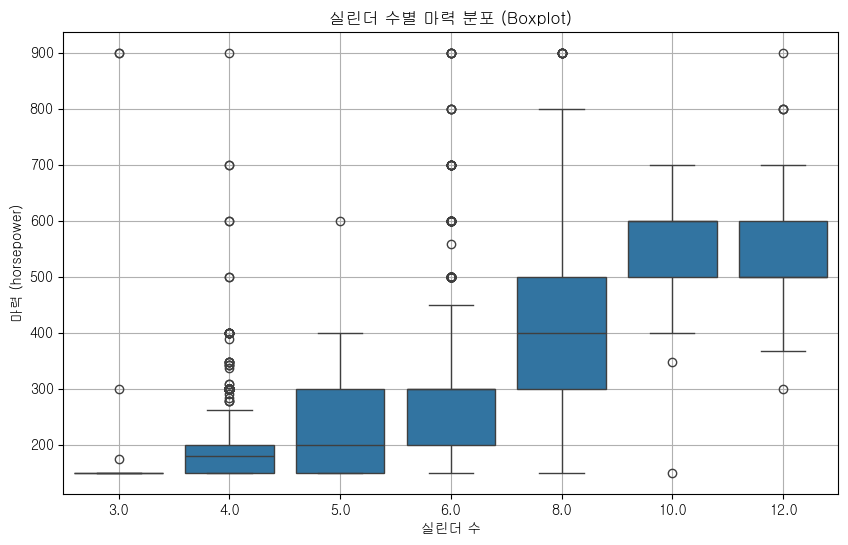

In [12]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='no_of_cylinders_clean', y='horsepower_clean', data=df)
plt.title('실린더 수별 마력 분포 (Boxplot)')
plt.xlabel('실린더 수')
plt.ylabel('마력 (horsepower)')
plt.grid(True)
plt.show()

실린더 분포를 확인 시 각각 5기통은 4기통, 6기통과 범위가 겹치고 10기통은 12기통과 범위가 겹친다

In [13]:
df['no_of_cylinders_clean'].value_counts().sort_index()

no_of_cylinders_clean
3.0       56
4.0     2993
5.0       53
6.0     3325
8.0     2986
10.0      53
12.0     366
Name: count, dtype: int64

In [14]:
# 마력 그룹 생성
df['hp_group'] = (df['horsepower_clean'] // 50) * 50

# 각 마력 그룹별 실린더 최빈값
cyl_mode_by_hp = df.dropna(subset=['no_of_cylinders_clean'])\
    .groupby('hp_group')['no_of_cylinders_clean']\
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)

# 모델별 최빈 실린더 수 fallback
model_mode_cyl = df.groupby('model')['no_of_cylinders_clean']\
    .agg(lambda x: x.dropna().mode().iloc[0] if not x.dropna().mode().empty else np.nan)

# 결측치 채우기 함수
def fill_cylinder(row):
    if pd.isnull(row['no_of_cylinders_clean']):
        hp_guess = cyl_mode_by_hp.get(row['hp_group'], np.nan)
        if not pd.isnull(hp_guess):
            return hp_guess
        return model_mode_cyl.get(row['model'], np.nan)
    return row['no_of_cylinders_clean']

df['no_of_cylinders_clean'] = df.apply(fill_cylinder, axis=1)



하지만 실린더의 분포를 확인해보면 3,5,10 기통은 매우 희소함을 확인할 수 있음

In [15]:
def map_cylinders(c):
    if c in [3, 4, 5]: return 4
    elif c == 6: return 6
    elif c in [7, 8]: return 8
    elif c in [10, 12]: return 12
    else: return np.nan

df['cyl_grouped'] = df['no_of_cylinders_clean'].apply(map_cylinders)


3,4,5 기통을 4기통 그룹으로 묶고 7,8을 8로 마지막으로 10,12기통을 12기통 그룹으로 묶어준다

In [16]:
df['cyl_grouped'].value_counts().sort_index()

cyl_grouped
4     3130
6     3396
8     3021
12     423
Name: count, dtype: int64

In [17]:
df['cyl_grouped'].isnull().sum()

np.int64(0)

In [18]:
df = df.drop(columns=['no_of_cylinders_clean'])
df = df.drop(columns=['no_of_cylinders'])
df = df.drop(columns=['horsepower'])

In [19]:
df.head(2)

,title,price_in_aed,kilometers,body_condition,mechanical_condition,seller_type,body_type,transmission_type,regional_specs,fuel_type,...,year,color,emirate,motors_trim,company,model,date_posted,horsepower_clean,hp_group,cyl_grouped
0,MITSUBISHI PAJERO 3.5L / 2013,26000,167390,Perfect inside and out,Perfect inside and out,Dealer,SUV,Automatic Transmission,GCC Specs,Gasoline,...,2013.0,Silver,Dubai,GLS,mitsubishi,pajero,13/05/2022,203.571429,200.0,6
1,chevrolet silverado,110000,39000,Perfect inside and out,Perfect inside and out,Dealer,SUV,Automatic Transmission,North American Specs,Gasoline,...,2018.0,White,Sharjah,1500 High Country,chevrolet,silverado,14/01/2022,400.000000,400.0,8


In [20]:
df = df.drop(columns=['horsepower_clean'])

### title 처리

타이틀은 게시글의 제목이며 이미 데이터에 타이틀에 포함된 브랜드와 모델명 년식이 존재하기에 중복된 정보를 포함하고 인코딩 처리도 곤란하기에 삭제를 한다

In [21]:
df = df.drop(columns=['title'])
df.head()

,price_in_aed,kilometers,body_condition,mechanical_condition,seller_type,body_type,transmission_type,regional_specs,fuel_type,steering_side,year,color,emirate,motors_trim,company,model,date_posted,hp_group,cyl_grouped
0,26000,167390,Perfect inside and out,Perfect inside and out,Dealer,SUV,Automatic Transmission,GCC Specs,Gasoline,Left Hand Side,2013.0,Silver,Dubai,GLS,mitsubishi,pajero,13/05/2022,200.0,6
1,110000,39000,Perfect inside and out,Perfect inside and out,Dealer,SUV,Automatic Transmission,North American Specs,Gasoline,Left Hand Side,2018.0,White,Sharjah,1500 High Country,chevrolet,silverado,14/01/2022,400.0,8
2,78000,200000,Perfect inside and out,Perfect inside and out,Dealer,Sedan,Automatic Transmission,GCC Specs,Gasoline,Left Hand Side,2014.0,Blue,Sharjah,E 300,mercedes-benz,e-class,05/05/2022,400.0,6
3,899000,27000,Perfect inside and out,Perfect inside and out,Dealer,Hard Top Convertible,Automatic Transmission,GCC Specs,Gasoline,Left Hand Side,2018.0,Red,Dubai,Standard,ferrari,488-spider,30/04/2022,600.0,8
4,33000,69000,Perfect inside and out,Perfect inside and out,Owner,Wagon,Manual Transmission,GCC Specs,Gasoline,Left Hand Side,2020.0,White,Dubai,Standard,renault,dokker,13/05/2022,150.0,4


### 년식 채우기

In [22]:
df['year'].isnull().sum()

np.int64(970)

결측치가 전체 데이터의 10퍼센트 정도로 꽤 높은 비율을 선보임    
따라서 평균값이나 최빈값으로 넣는 것보단 각 회사 + 모델별 최빈값으로 채워넣기로 결정

In [23]:
# 그룹별 연식 평균 계산
year_by_model = df.groupby(['company', 'model'])['year'].transform('median')

# 결측값에만 채움
df['year'] = df['year'].fillna(year_by_model)
df['year'].isnull().sum()

np.int64(69)

In [24]:
df['year'] = df['year'].fillna(df.groupby('company')['year'].transform('median'))
df['year'].isnull().sum()

np.int64(11)

In [25]:
# 고급 대체 방식
group_medians = df.groupby(['company', 'model'])['year'].median()

def fill_year(row):
    if pd.isnull(row['year']):
        key = (row['company'], row['model'])
        return group_medians.get(key, np.nan)
    else:
        return row['year']

df['year'] = df.apply(fill_year, axis=1)


In [26]:
# 1. year 형식 통일
df['year'] = pd.to_numeric(df['year'], errors='coerce')

# 2. 그룹별 평균으로 다시 채움 (1차 시도)
df['year'] = df.apply(fill_year, axis=1)
# 3. 아직도 남았다면 회사 단위 평균으로 채움
df['year'] = df['year'].fillna(df.groupby('company')['year'].transform('median'))

# 4. 그래도 남으면 전체 중앙값으로 강제 채움
df['year'] = df['year'].fillna(df['year'].median())
df['year'].isnull().sum()

np.int64(0)

### 모터트림 채우기

In [27]:
trim_mode_by_model = df.groupby(['company', 'model'])['motors_trim']\
                       .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)

def fill_trim(row):
    if pd.isnull(row['motors_trim']):
        return trim_mode_by_model.get((row['company'], row['model']), np.nan)
    return row['motors_trim']

df['motors_trim'] = df.apply(fill_trim, axis=1)
df['motors_trim'].isnull().sum()

np.int64(1)

In [28]:
df['motors_trim'] = df['motors_trim'].fillna(
    df.groupby('company')['motors_trim'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)
df['motors_trim'].isnull().sum()

np.int64(0)

모터트림은 제조사마다 이름이 다르고 결측치가 28개 밖에 되지 않아 브랜드와 모델별 최빈값으로 적용

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9970 entries, 0 to 9969
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   price_in_aed          9970 non-null   int64  
 1   kilometers            9970 non-null   int64  
 2   body_condition        9970 non-null   object 
 3   mechanical_condition  9970 non-null   object 
 4   seller_type           9970 non-null   object 
 5   body_type             9970 non-null   object 
 6   transmission_type     9970 non-null   object 
 7   regional_specs        9970 non-null   object 
 8   fuel_type             9970 non-null   object 
 9   steering_side         9970 non-null   object 
 10  year                  9970 non-null   float64
 11  color                 9970 non-null   object 
 12  emirate               9970 non-null   object 
 13  motors_trim           9970 non-null   object 
 14  company               9970 non-null   object 
 15  model                

## 2-2. Encoding

### 라벨링

In [30]:
cat_cols = [
    'body_condition', 'mechanical_condition', 'seller_type',
    'body_type', 'transmission_type', 'regional_specs', 'fuel_type',
    'steering_side', 'color', 'emirate', 'motors_trim', 'company', 'model'
]

트리 기반 모델을 사용할 예정이므로 범주형 컬럼을 모두 라벨링 함

In [31]:
df['date_posted'] = pd.to_datetime(df['date_posted'])
df['post_year'] = df['date_posted'].dt.year
df['post_month'] = df['date_posted'].dt.month
df['post_dayofweek'] = df['date_posted'].dt.dayofweek

중고차 판매 가격은 시즌에 따라 달리질 수 있을거라 판단하여 파생컬럼 만듬

In [32]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

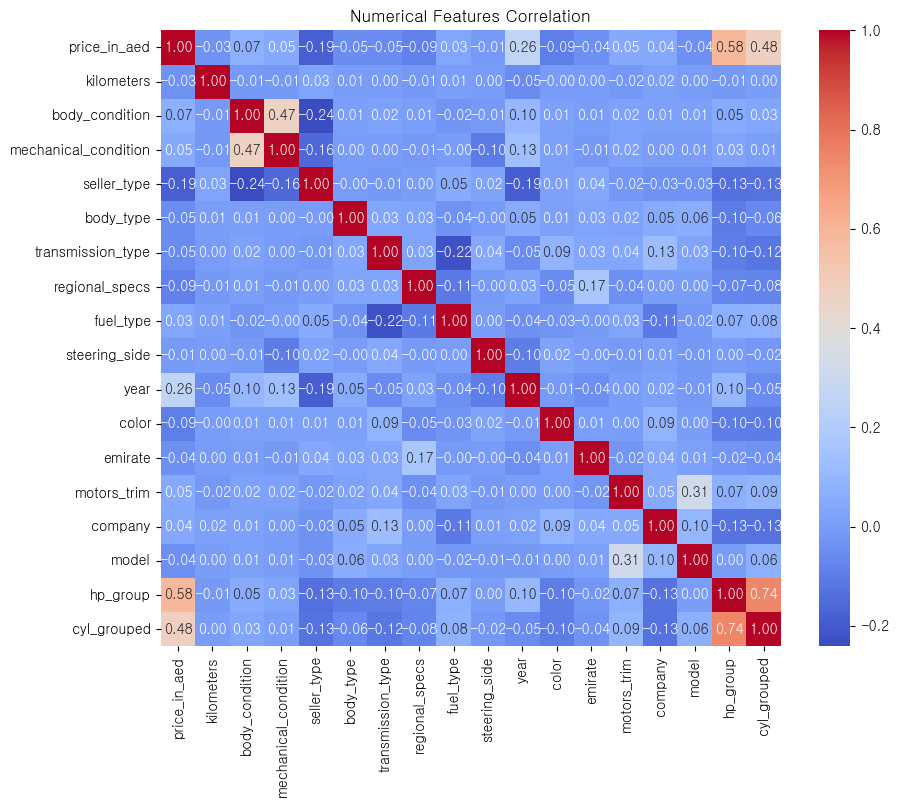

In [33]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = df[numeric_cols].corr(method='pearson')
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Numerical Features Correlation")
plt.show()


<Axes: xlabel='kilometers', ylabel='Count'>

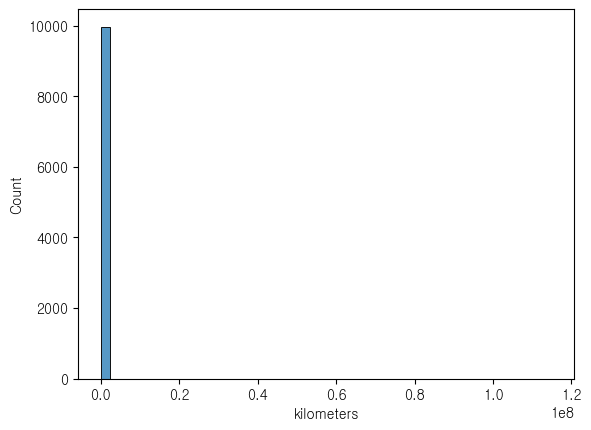

In [34]:
df['kilometers'].describe()
sns.histplot(df['kilometers'], bins=50)


### 킬로미터 로그변환

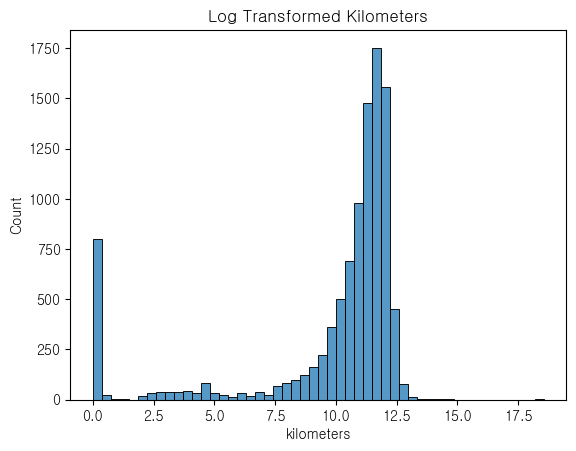

In [35]:
sns.histplot(np.log1p(df['kilometers']), bins=50)
plt.title('Log Transformed Kilometers')
plt.show()

In [36]:
# 이상치 제거 (예: 1백만 km 초과)
df = df[df['kilometers'] <= 1_000_000]

# log1p 처리
df['kilometers_log'] = np.log1p(df['kilometers'])


In [37]:
bins = [0, 30000, 60000, 100000, 150000, 200000, 1_000_000]
labels = ['신차급', '중고1', '중고2', '보통', '고주행', '과도주행']
df['km_bin'] = pd.cut(df['kilometers'], bins=bins, labels=labels)


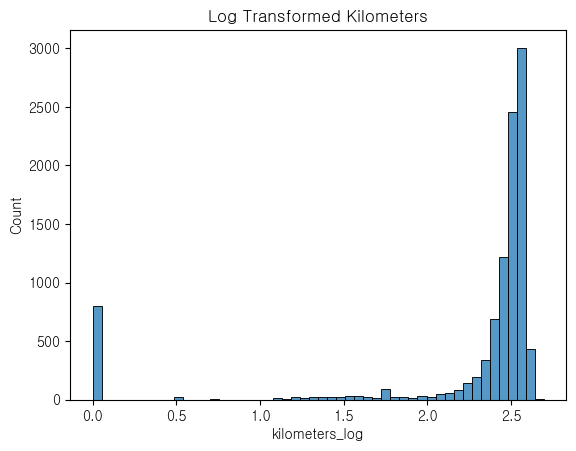

In [38]:
sns.histplot(np.log1p(df['kilometers_log']), bins=50)
plt.title('Log Transformed Kilometers')
plt.show()

### 가격 로그 변환

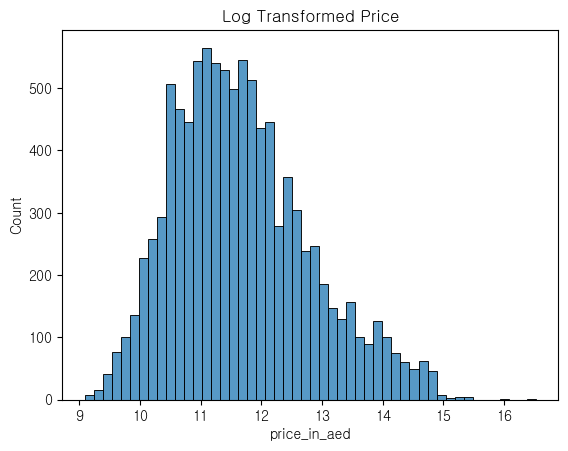

In [39]:
sns.histplot(np.log1p(df['price_in_aed']), bins=50)
plt.title('Log Transformed Price')
plt.show()

In [40]:
df['price_log'] = np.log1p(df['price_in_aed'])

# 3. Correlation Analysis

## 3-1. 각 독립변수와 가격과의 관계

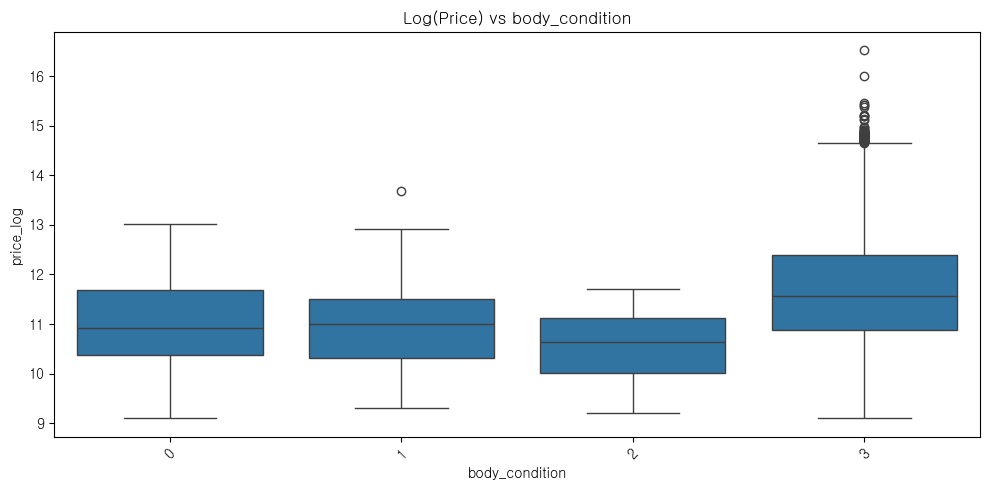

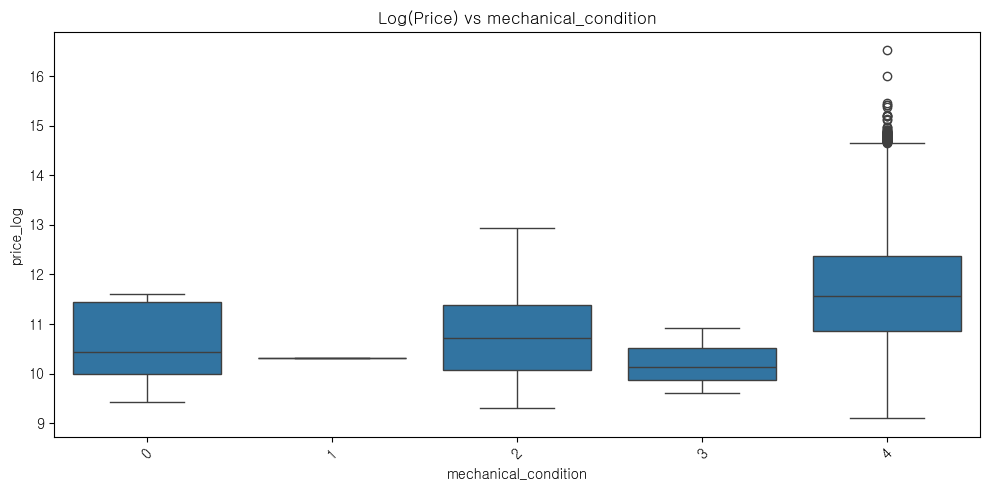

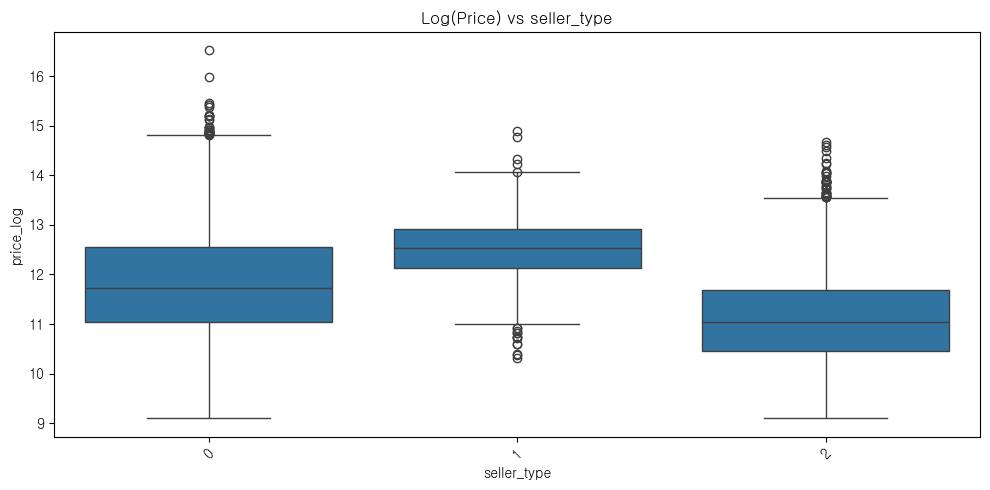

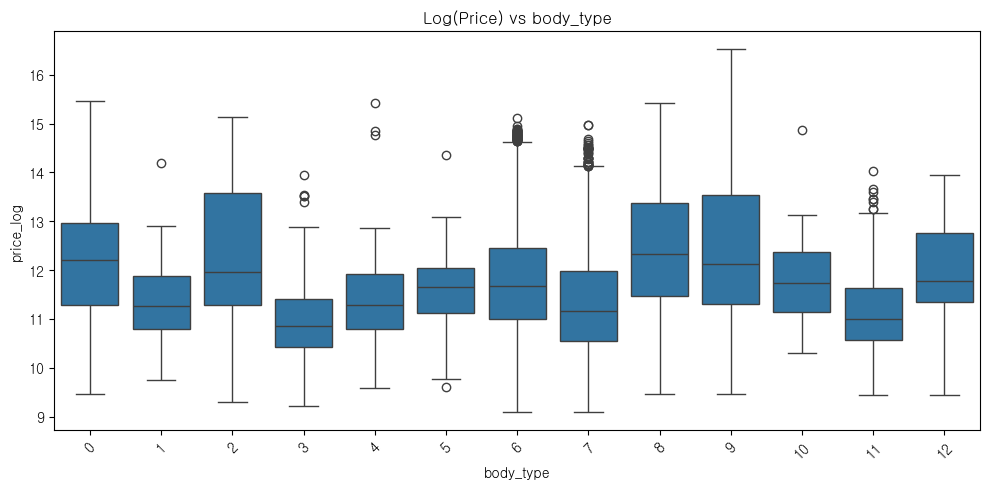

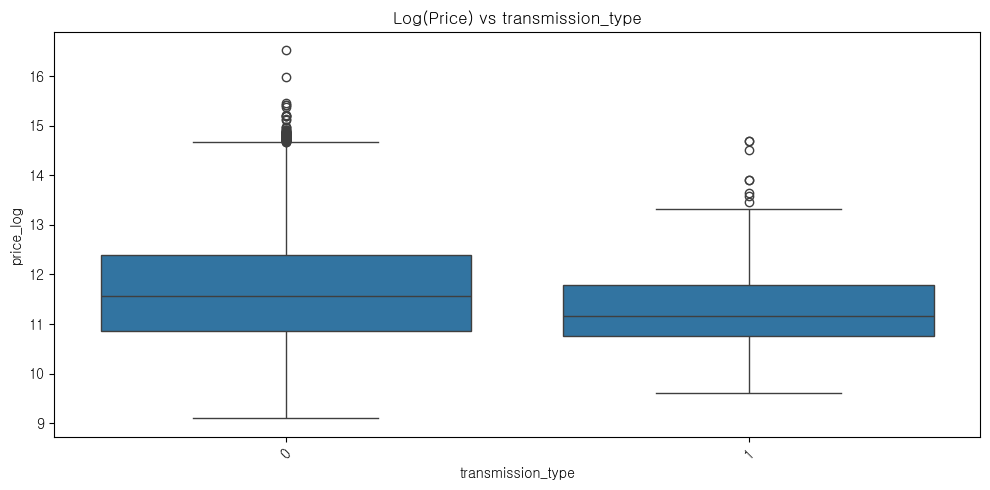

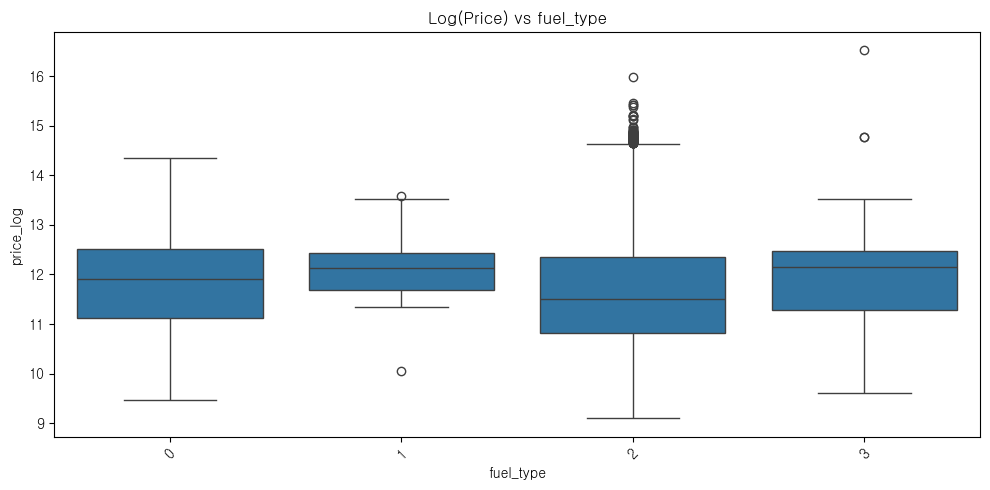

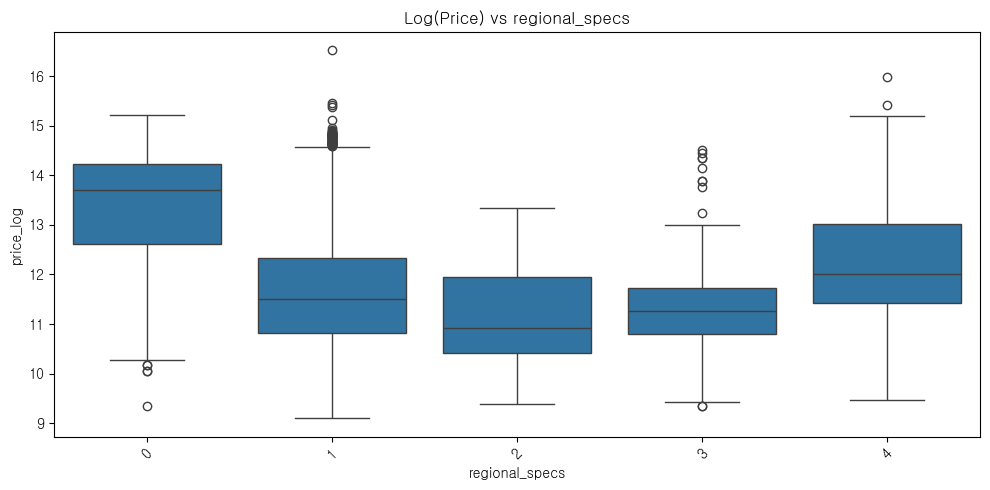

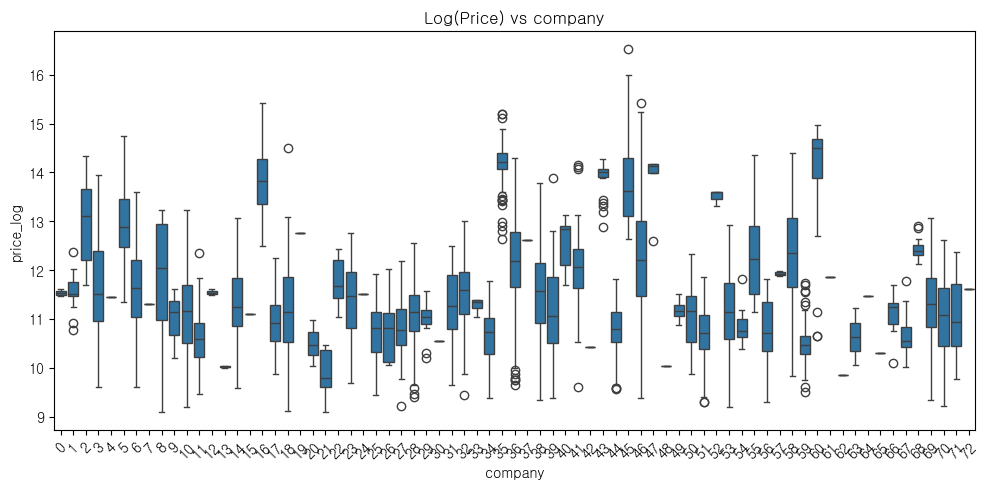

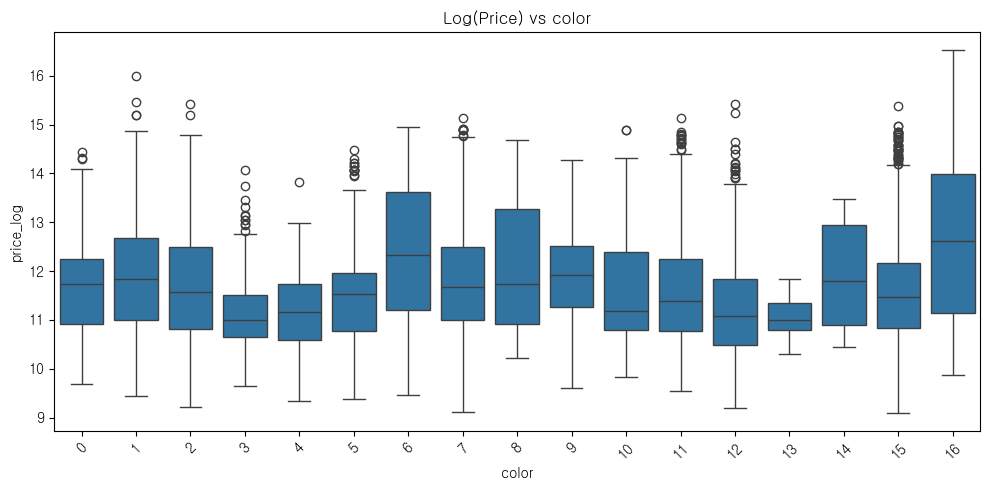

In [41]:
# 범주형 변수들과의 관계
categorical_cols = ['body_condition', 'mechanical_condition', 'seller_type', 
                    'body_type', 'transmission_type', 'fuel_type', 
                    'regional_specs', 'company', 'color']

for col in categorical_cols:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df, x=col, y='price_log')
    plt.title(f'Log(Price) vs {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


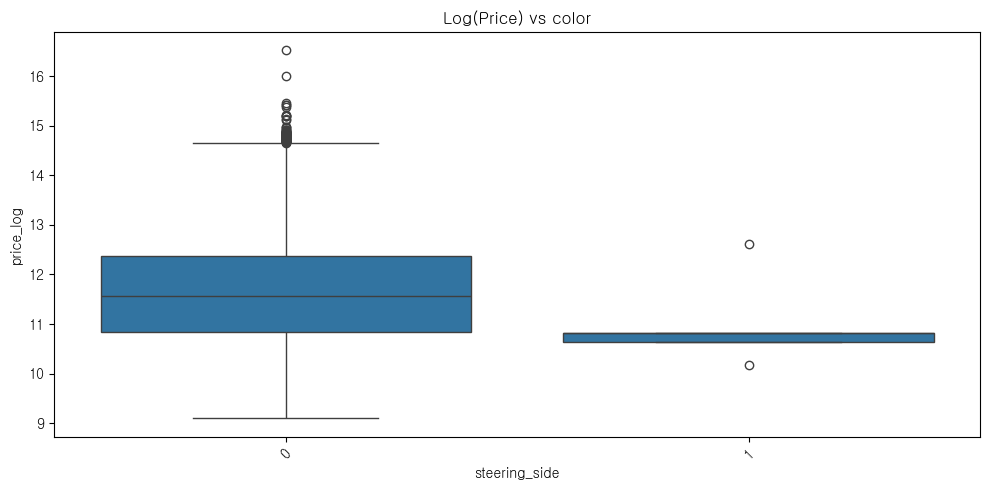

In [42]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='steering_side', y='price_log')
plt.title(f'Log(Price) vs {col}')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

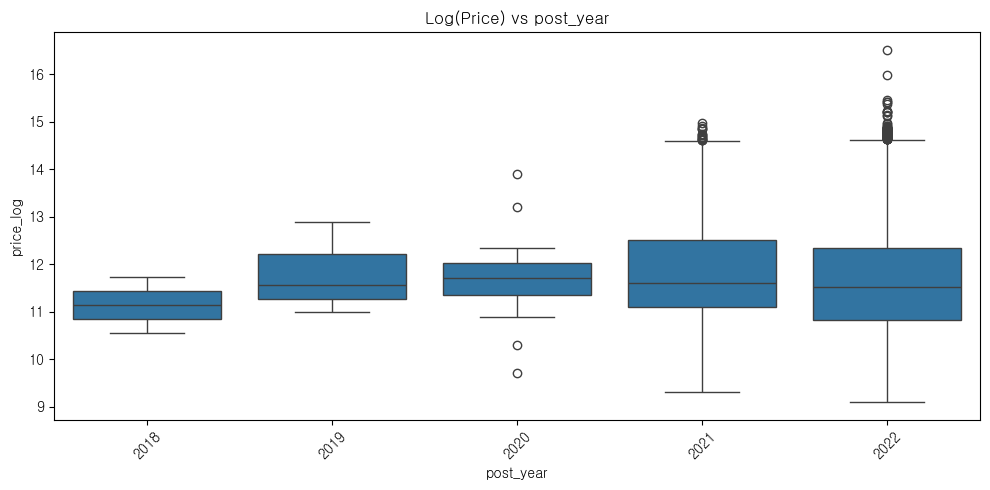

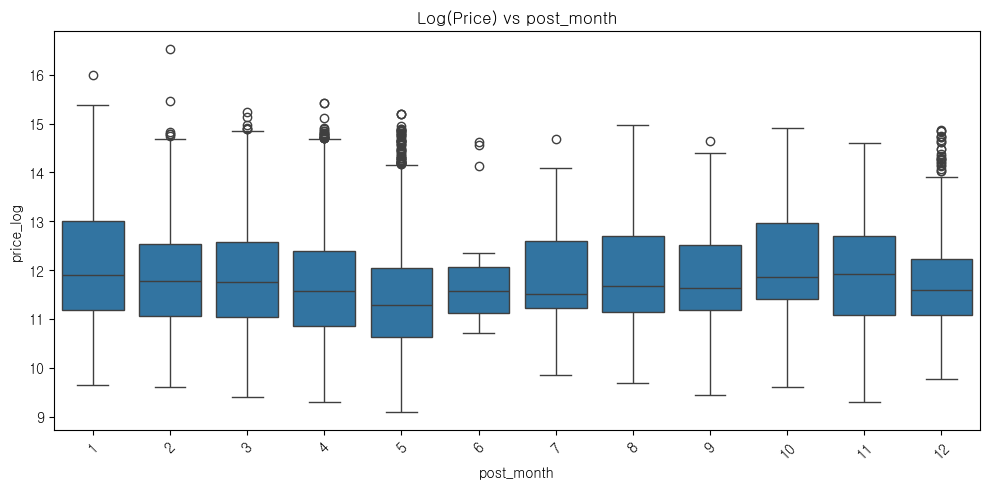

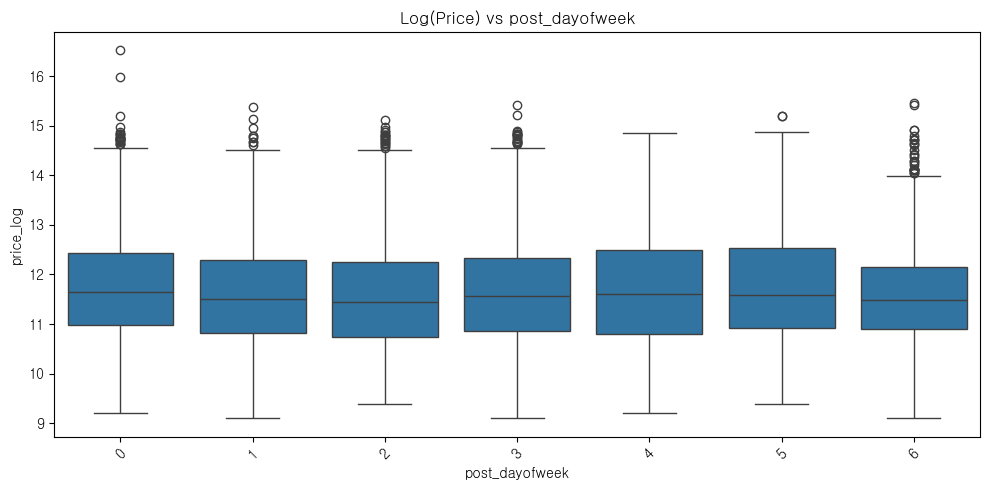

In [43]:
# 시계열 변수들과의 관계
df['post_year'] = df['date_posted'].dt.year
df['post_month'] = df['date_posted'].dt.month
df['post_dayofweek'] = df['date_posted'].dt.dayofweek
categorical_cols1 = ['post_year', 'post_month', 'post_dayofweek']

for col in categorical_cols1:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df, x=col, y='price_log')
    plt.title(f'Log(Price) vs {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [44]:
df['is_recent_year'] = (df['post_year'] >= 2021).astype(int)
def map_year_group(y):
    if y <= 2019:
        return 0  # 구형차
    elif y == 2020:
        return 1  # 중간
    else:
        return 2  # 신형차

df['year_group'] = df['post_year'].apply(map_year_group)
year_median = df.groupby('post_year')['price_log'].transform('median')
df['year_price_dev'] = df['price_log'] - year_median

In [45]:
df['is_high_outlier_month'] = df['post_month'].isin([4, 5, 12]).astype(int)

## 3-2. 지역, 브랜드별 분포확인

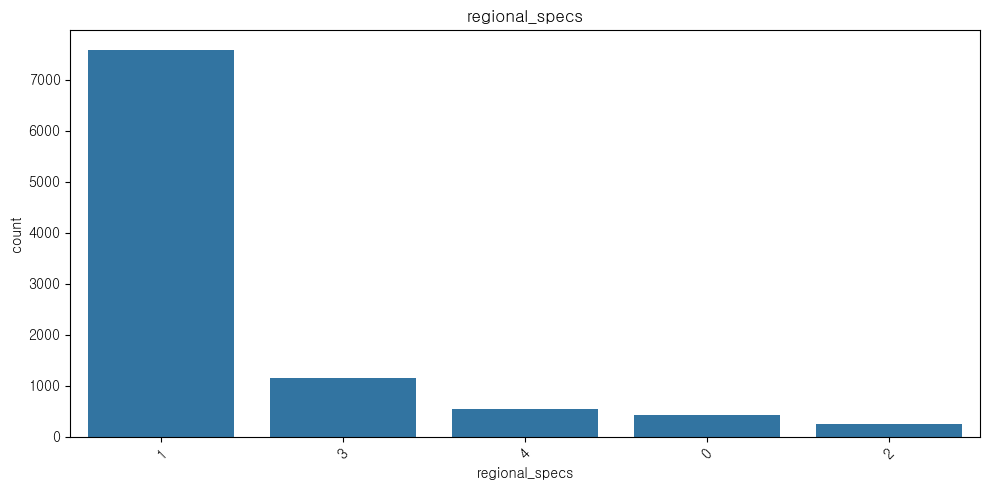

In [46]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='regional_specs', order=df['regional_specs'].value_counts().index)
plt.xticks(rotation=45)
plt.title('regional_specs')
plt.tight_layout()
plt.show()

# 4. Outliner Analysis

In [47]:
# 지역별 평균 가격 계산
region_price_mean = df.groupby('regional_specs')['price_in_aed'].mean()

# 지역별 평균 가격을 파생 변수로 추가
df['region_price_mean'] = df['regional_specs'].map(region_price_mean)
df = df.drop(columns=['regional_specs'])

In [48]:
df['mechanical_condition'] = df['mechanical_condition'].replace(1, 0)

<Axes: xlabel='color', ylabel='company'>

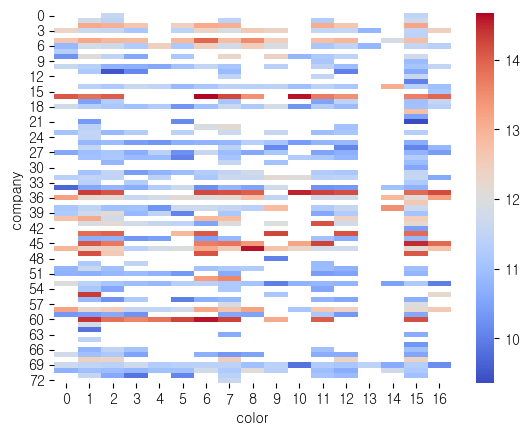

In [49]:
grouped = df.groupby(['company', 'color'])['price_log'].mean().unstack()
sns.heatmap(grouped, cmap='coolwarm')

In [50]:
# 브랜드+모델 조합 평균 가격 계산
company_model_avg = df.groupby(['company', 'model'])['price_log'].mean().reset_index()
company_model_avg.rename(columns={'price_log': 'company_model_avg_price'}, inplace=True)

# 원본 데이터프레임에 병합
df = pd.merge(df, company_model_avg, on=['company', 'model'], how='left')

# 정규화된 가격(중심에서 얼마나 떨어졌는지)
df['price_log_dev'] = df['price_log'] - df['company_model_avg_price']


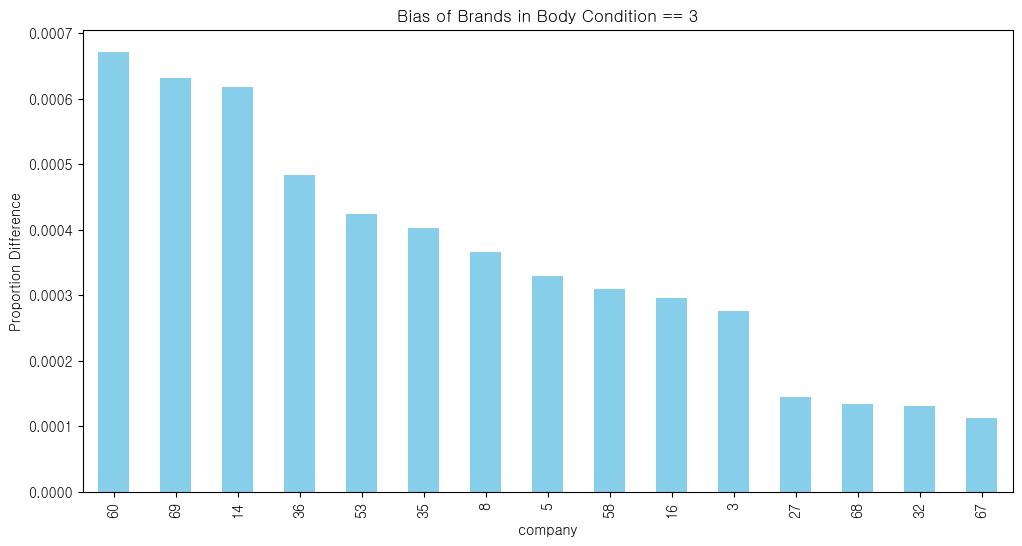

In [51]:
# body_condition이 3인 차량 브랜드 분포
high_condition_brands = df[df['body_condition'] == 3]['company'].value_counts(normalize=True)
total_brand_dist = df['company'].value_counts(normalize=True)

# 비교: 비율 차이
brand_bias = (high_condition_brands - total_brand_dist).sort_values(ascending=False)
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
brand_bias[:15].plot(kind='bar', color='skyblue')
plt.title("Bias of Brands in Body Condition == 3")
plt.ylabel("Proportion Difference")
plt.show()


In [52]:
df['body_type_median_price'] = df.groupby('body_type')['price_log'].transform('median')

In [53]:
df['mechanical_condition_median_price'] = df.groupby('mechanical_condition')['price_log'].transform('median')

# 5. 모델 학습 및 평가

In [54]:
drop_cols = [
    'price_in_aed',
    'kilometers',
    'color',
    'post_dayofweek',
    'post_month',
    'post_year',
    'region_price_mean',
    'company_model_avg_price',
    'body_type',
    'mechanical_condition',
    'body_type_median_price',
    'mechanical_condition_median_price',
    'year_group'
]

df_model = df.drop(columns=drop_cols)


In [55]:
df_model1 = df_model.drop(columns= 'price_log_dev', axis = 1)

In [56]:
df_model1.columns.to_list()

['body_condition',
 'seller_type',
 'transmission_type',
 'fuel_type',
 'steering_side',
 'year',
 'emirate',
 'motors_trim',
 'company',
 'model',
 'date_posted',
 'hp_group',
 'cyl_grouped',
 'kilometers_log',
 'km_bin',
 'price_log',
 'is_recent_year',
 'year_price_dev',
 'is_high_outlier_month']

In [57]:
# 타겟과 피처 분리
target = 'price_log'
X = df_model.drop(columns=[target])
X1 = X.drop(columns='price_log_dev' ,axis= 1)
X2 = X1.drop(columns='year_price_dev' ,axis= 1)
y = df_model1[target]

X3 = X2.drop(columns=['date_posted'])  # 또는 Timestamp 형식인 컬럼

X3['km_bin'] = le.fit_transform(X3['km_bin'])



# 학습/검증 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X3, y, test_size=0.2, random_state=42
)

# 1. Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

# 2. XGBoost
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)

# 평가 함수
def evaluate(model_name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"[{model_name}] RMSE: {rmse:.4f}, R²: {r2:.4f}")

evaluate("Random Forest", y_test, rf_preds)
evaluate("XGBoost", y_test, xgb_preds)

[Random Forest] RMSE: 0.3338, R²: 0.9154
[XGBoost] RMSE: 0.3030, R²: 0.9303


In [58]:
X3.corrwith(y).sort_values(ascending=False).head(10)

hp_group          0.665656
cyl_grouped       0.519443
year              0.461767
km_bin            0.399527
body_condition    0.116619
motors_trim       0.019811
company           0.000416
is_recent_year    0.000276
model            -0.007070
steering_side    -0.013181
dtype: float64

In [61]:
X3.corrwith(y).sort_values(ascending=False)

hp_group                 0.665656
cyl_grouped              0.519443
year                     0.461767
km_bin                   0.399527
body_condition           0.116619
motors_trim              0.019811
company                  0.000416
is_recent_year           0.000276
model                   -0.007070
steering_side           -0.013181
fuel_type               -0.018999
transmission_type       -0.066281
emirate                 -0.080807
is_high_outlier_month   -0.145277
seller_type             -0.285678
kilometers_log          -0.537432
dtype: float64

In [59]:
scores = cross_val_score(xgb, X3, y, scoring='r2', cv=5)

for i, score in enumerate(scores, 1):
    print(f"Fold {i}: R² = {score:.4f}")
    
print("CV R² 평균:", scores.mean())

Fold 1: R² = 0.9219
Fold 2: R² = 0.9243
Fold 3: R² = 0.9283
Fold 4: R² = 0.9209
Fold 5: R² = 0.9340
CV R² 평균: 0.9258626701929007


In [60]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf_scores = cross_val_score(rf, X3, y, scoring='r2', cv=5, n_jobs=-1)

for i, score in enumerate(rf_scores, 1):
    print(f"Fold {i}: R² = {score:.4f}")
print("CV R² 평균:", rf_scores.mean())

Fold 1: R² = 0.9062
Fold 2: R² = 0.9041
Fold 3: R² = 0.9121
Fold 4: R² = 0.9062
Fold 5: R² = 0.9208
CV R² 평균: 0.9098737700568433
